# Ablation & ensembling results

Analysis of the prompt-length ablation (k ∈ {5, 10, 20}), the mBERT vs XLM-R comparison,
length-normalised scoring and soft-prompt ensembling, for both inflection variants.

**Where the inputs come from** (all paths relative to the project root, as written by the Slurm jobs):

| What | Path | Written by |
|---|---|---|
| Per-prompt evaluation (token accuracy vs zero-shot) | `results/ablation_<variant>/<model>/<lang>/eval_P<k>_seed<s>.json` | `ablation_train.slurm` → `prompt_tuning_eval.py` |
| Candidate-ranking EM for every member, α and ensemble | `results/ablation_<variant>/<model>/<lang>/ensemble.json` | `ablation_ensemble.slurm` → `prompt_ensemble.py` |
| Training curves | `checkpoints/ablation_<variant>/<model>/<lang>/P<k>_seed<s>/history_<lang>_P<k>.json` | `prompt_tuning_train.py` |
| Discrete-template baseline (optional) | `results/baseline_probe/summary.tsv` | `baseline_probe.slurm` |

`<variant>` is `keep` (all facts, Russian lowercased) or `drop` (facts with malformed ru/el inflections removed).

**Running it.** On Snellius, open it from the project folder (`pip install jupyter` in the env if needed).
To run on your laptop instead, copy the result folders first, from the project root:

```bash
scp -r scur0540@snellius.surf.nl:~/Multilingual_NLP_Project/results/ablation_keep  results/
scp -r scur0540@snellius.surf.nl:~/Multilingual_NLP_Project/results/ablation_drop  results/
scp -r scur0540@snellius.surf.nl:~/Multilingual_NLP_Project/results/baseline_probe results/
# training curves only (small JSON files, skips the .pt checkpoints):
rsync -av --include='*/' --include='history_*.json' --exclude='*' \
    scur0540@snellius.surf.nl:~/Multilingual_NLP_Project/checkpoints/ ./checkpoints/
```

Figures are saved to `results/analysis_figures/`.

In [14]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

# Project root = the folder that contains pipeline_v1/ (works from any subfolder).
ROOT = Path.cwd().resolve()
while not (ROOT / "pipeline_v1").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

VARIANTS = {
    "keep": {"results": ROOT / "results" / "ablation_keep",
             "checkpoints": ROOT / "checkpoints" / "ablation_keep"},
    "drop": {"results": ROOT / "results" / "ablation_drop",
             "checkpoints": ROOT / "checkpoints" / "ablation_drop"},
}
BASELINE = ROOT / "results" / "baseline_probe" / "summary.tsv"
FIG_DIR = ROOT / "results" / "analysis_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Variant used for the single-variant sections (length normalisation, ensembles, curves).
FOCUS = "keep"

print(f"Project root: {ROOT}")
for name, paths in VARIANTS.items():
    for kind, path in paths.items():
        print(f"  {name:<5} {kind:<12} {'found  ' if path.is_dir() else 'MISSING'} {path}")
print(f"  baseline           {'found  ' if BASELINE.exists() else 'MISSING'} {BASELINE}")

Project root: /gpfs/home6/scur0540/Multilingual_NLP_Project
  keep  results      found   /gpfs/home6/scur0540/Multilingual_NLP_Project/results/ablation_keep
  keep  checkpoints  found   /gpfs/home6/scur0540/Multilingual_NLP_Project/checkpoints/ablation_keep
  drop  results      found   /gpfs/home6/scur0540/Multilingual_NLP_Project/results/ablation_drop
  drop  checkpoints  found   /gpfs/home6/scur0540/Multilingual_NLP_Project/checkpoints/ablation_drop
  baseline           found   /gpfs/home6/scur0540/Multilingual_NLP_Project/results/baseline_probe/summary.tsv


In [15]:
# --- Colours (validated categorical palette; identity follows the entity) ---
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
               "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
LANG_ORDER = ["en", "nl", "ru", "el", "ko"]
MODEL_ORDER = ["mbert_base", "xlmr_base"]
MODEL_LABELS = {"mbert_base": "mBERT (WordPiece)", "xlmr_base": "XLM-R (SentencePiece)"}
MODEL_COLORS = {"mbert_base": "#4a3aa7", "xlmr_base": "#008300"}
SYSTEM_ORDER = ["zero_shot", "best_single", "uniform", "learned"]
SYSTEM_LABELS = {"zero_shot": "Zero-shot", "best_single": "Best single prompt",
                 "uniform": "Uniform ensemble", "learned": "Learned weights"}
SYSTEM_COLORS = dict(zip(SYSTEM_ORDER, CATEGORICAL[:4]))
# k is ordinal, so it gets one sequential hue (light = short prompt, dark = long).
K_RAMP = ["#86b6ef", "#2a78d6", "#104281", "#0d366b"]
BLUES = LinearSegmentedColormap.from_list("blues", ["#f0f6fd", "#9ec5f4", "#2a78d6", "#0d366b"])

INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "font.size": 10,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "axes.grid": True, "axes.grid.axis": "y", "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.markersize": 6, "legend.frameon": False,
    "legend.labelcolor": INK2, "figure.dpi": 110,
})


def ordered(values, order):
    """Known values in the preferred order, then any others alphabetically."""
    values = list(dict.fromkeys(values))
    return [v for v in order if v in values] + sorted(v for v in values if v not in order)


def lang_colors(langs):
    return {lang: CATEGORICAL[i % len(CATEGORICAL)] for i, lang in enumerate(ordered(langs, LANG_ORDER))}


def k_colors(ks):
    return {k: K_RAMP[min(i, len(K_RAMP) - 1)] for i, k in enumerate(sorted(ks))}


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

In [16]:
EVAL_FILE = re.compile(r"^eval_P(\d+)_seed(\d+)\.json$")
MEMBER = re.compile(r"^P(\d+)_s(\d+)$")
HISTORY_DIR = re.compile(r"^P(\d+)_seed(\d+)$")


def lang_dirs(results_root):
    if not results_root.is_dir():
        return
    for model_dir in sorted(p for p in results_root.iterdir() if p.is_dir()):
        for lang_dir in sorted(p for p in model_dir.iterdir() if p.is_dir()):
            yield model_dir.name, lang_dir.name, lang_dir


eval_rows, member_rows, system_rows, weight_rows, selection_rows, history_rows = [], [], [], [], [], []

for variant, paths in VARIANTS.items():
    for model, lang, folder in lang_dirs(paths["results"]):
        # Per-prompt evaluation: teacher-forced token accuracy at the gold masks.
        for file in sorted(folder.glob("eval_P*_seed*.json")):
            k, seed = map(int, EVAL_FILE.match(file.name).groups())
            result = json.loads(file.read_text(encoding="utf-8"))
            zero = result.get("zero_shot", {}).get("accuracy", np.nan)
            eval_rows.append(dict(variant=variant, model=model, lang=lang, k=k, seed=seed,
                                  token_acc_zero_shot=zero,
                                  token_acc_prompt=result["prompt_tuned"]["accuracy"],
                                  n_test=result["metadata"]["num_evaluation_examples"]))

        # Candidate ranking, length normalisation and ensembles.
        ens_file = folder / "ensemble.json"
        if not ens_file.exists():
            continue
        ens = json.loads(ens_file.read_text(encoding="utf-8"))
        selected = float(ens["summary"]["selected_alpha"])
        selection_rows.append(dict(variant=variant, model=model, lang=lang, alpha=selected,
                                   best_member=ens["summary"]["best_member"],
                                   n_test=ens["metadata"]["splits"]["eval"]["num_scored"]))

        for alpha_key, entry in ens["by_alpha"].items():
            alpha = float(alpha_key)
            for member, res in entry["members"].items():
                match = MEMBER.match(member)
                k, seed = (int(match.group(1)), int(match.group(2))) if match else (0, np.nan)
                for subset in ("all", "single", "multi"):
                    member_rows.append(dict(variant=variant, model=model, lang=lang, alpha=alpha,
                                            member=member, k=k, seed=seed, subset=subset,
                                            fit=res["fit"][subset]["macro"],
                                            test=res["eval"][subset]["macro"],
                                            test_micro=res["eval"][subset]["micro"],
                                            n=res["eval"][subset]["n"]))
            for system in ("uniform", "learned"):
                if system in entry:
                    for subset in ("all", "single", "multi"):
                        system_rows.append(dict(variant=variant, model=model, lang=lang, alpha=alpha,
                                                system=system, subset=subset,
                                                fit=entry[system]["fit"][subset]["macro"],
                                                test=entry[system]["eval"][subset]["macro"]))
            if alpha == selected and "learned" in entry:
                for member, weight in entry["learned"]["weights"].items():
                    weight_rows.append(dict(variant=variant, model=model, lang=lang,
                                            member=member, weight=weight))

    # Training curves.
    ckpt_root = paths["checkpoints"]
    if ckpt_root.is_dir():
        for history in ckpt_root.glob("*/*/P*_seed*/history_*.json"):
            k, seed = map(int, HISTORY_DIR.match(history.parent.name).groups())
            model, lang = history.parent.parent.parent.name, history.parent.parent.name
            for row in json.loads(history.read_text(encoding="utf-8")):
                history_rows.append(dict(variant=variant, model=model, lang=lang, k=k, seed=seed, **row))

evals = pd.DataFrame(eval_rows)
members = pd.DataFrame(member_rows)
systems = pd.DataFrame(system_rows)
weights = pd.DataFrame(weight_rows)
selection = pd.DataFrame(selection_rows)
history = pd.DataFrame(history_rows)

for name, frame in [("evals", evals), ("members", members), ("systems", systems),
                    ("weights", weights), ("selection", selection), ("history", history)]:
    print(f"{name:<10} {len(frame):>6} rows")

assert len(members), "No ensemble.json files found - check the paths printed above."
VARIANT_NAMES = [v for v in VARIANTS if v in set(members.variant)]
MODELS = ordered(members.model, MODEL_ORDER)
LANGS = ordered(members.lang, LANG_ORDER)
KS = sorted(int(k) for k in members.k.unique() if k > 0)
LANG_COLORS = lang_colors(LANGS)
K_COLORS = k_colors(KS)
print("variants:", VARIANT_NAMES, "| models:", MODELS, "| langs:", LANGS, "| k:", KS)

# Member EM at the alpha that validation selected for that (variant, model, lang).
at_selected = members.merge(selection[["variant", "model", "lang", "alpha"]],
                            on=["variant", "model", "lang", "alpha"])

evals          60 rows
members      1200 rows
systems       600 rows
weights        80 rows
selection      20 rows
history       600 rows
variants: ['keep', 'drop'] | models: ['mbert_base', 'xlmr_base'] | langs: ['en', 'nl', 'ru', 'el', 'ko'] | k: [5, 10, 20]


## Template Baseline

In [17]:
if BASELINE.exists():
    baseline = pd.read_csv(BASELINE, sep="\t")
    display(baseline.round(3))
else:
    print(f"No baseline at {BASELINE}")

,model,lang,em_all,em_single,em_multi,n_all,n_single,n_multi
0,mbert_base,en,0.139,0.180,0.048,1152,618,534
1,mbert_base,nl,0.150,0.241,0.026,1161,471,690
2,mbert_base,ru,0.019,0.052,0.007,1156,172,984
3,mbert_base,el,0.054,0.068,0.025,1159,71,1088
4,mbert_base,ko,0.038,0.118,0.016,1141,141,1000
5,xlmr_base,en,0.106,0.155,0.040,1161,476,685
6,xlmr_base,nl,0.068,0.134,0.033,1161,298,863
7,xlmr_base,ru,0.057,0.145,0.038,1161,114,1047
8,xlmr_base,el,0.063,0.132,0.036,1161,103,1058
9,xlmr_base,ko,0.050,0.154,0.028,1157,155,1002


## Does longer prompts help

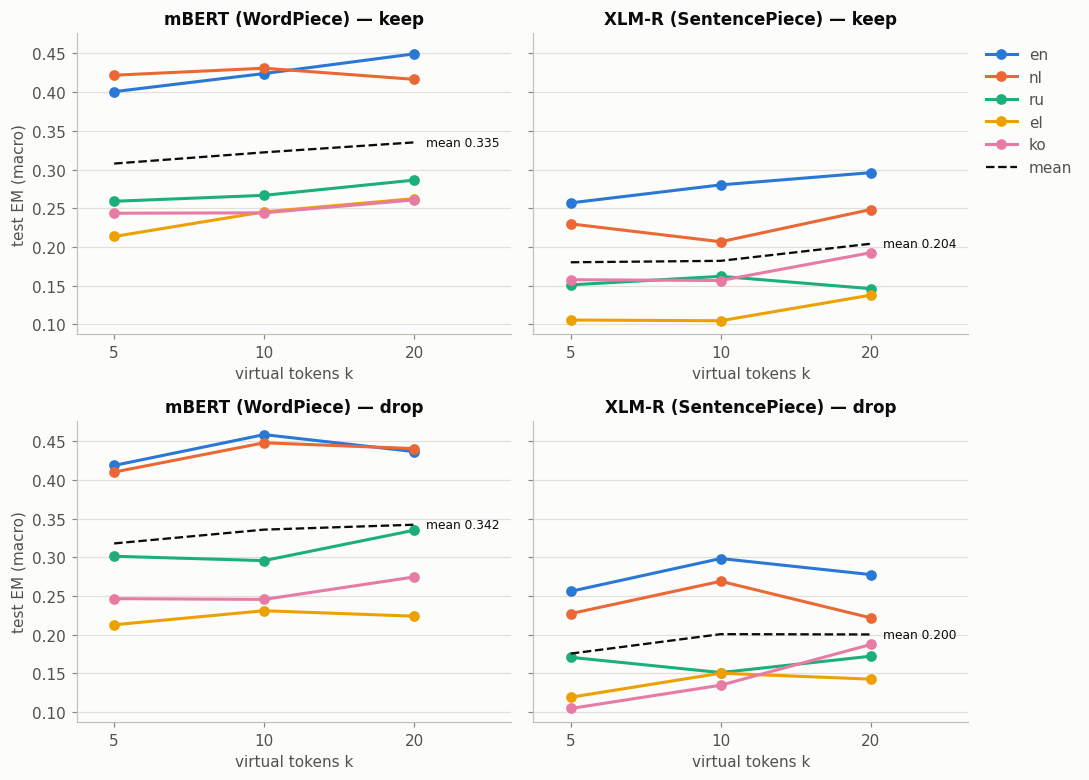

**Test EM by k** (rows: variant / model / language)

k                           5      10     20
variant model      lang                     
drop    mbert_base el    0.213  0.231  0.224
                   en    0.419  0.458  0.436
                   ko    0.247  0.246  0.275
                   nl    0.410  0.448  0.440
                   ru    0.301  0.296  0.335
        xlmr_base  el    0.119  0.150  0.143
                   en    0.256  0.298  0.278
                   ko    0.105  0.135  0.187
                   nl    0.227  0.269  0.222
                   ru    0.171  0.151  0.172
keep    mbert_base el    0.214  0.245  0.262
                   en    0.400  0.424  0.449
                   ko    0.244  0.244  0.261
                   nl    0.422  0.431  0.416
                   ru    0.259  0.267  0.286
        xlmr_base  el    0.106  0.105  0.138
                   en    0.257  0.280  0.296
                   ko    0.158  0.157  0.193
                   nl    0.230  0.207  0.248
                   ru    0.151  0.162  0.146

In [18]:
capacity = (at_selected[(at_selected.subset == "all") & (at_selected.k > 0)]
            .groupby(["variant", "model", "lang", "k"], as_index=False).test.mean())

fig, axes = plt.subplots(len(VARIANT_NAMES), len(MODELS), figsize=(5 * len(MODELS), 3.6 * len(VARIANT_NAMES)),
                         sharey=True, squeeze=False)
positions = {k: i for i, k in enumerate(KS)}
for r, variant in enumerate(VARIANT_NAMES):
    for c, model in enumerate(MODELS):
        ax = axes[r, c]
        data = capacity[(capacity.variant == variant) & (capacity.model == model)]
        for lang in LANGS:
            d = data[data.lang == lang].sort_values("k")
            ax.plot(d.k.map(positions), d.test, marker="o", color=LANG_COLORS[lang], label=lang)
        mean = data.groupby("k").test.mean()
        ax.plot([positions[k] for k in mean.index], mean.values, color=INK, linestyle="--",
                linewidth=1.5, label="mean")
        # One selective label: the language mean at the longest prompt.
        ax.annotate(f"mean {mean.iloc[-1]:.3f}", (positions[mean.index[-1]], mean.iloc[-1]),
                    textcoords="offset points", xytext=(8, 0), va="center", color=INK, fontsize=8)
        ax.set_xlim(-0.25, len(KS) - 0.35)
        ax.set_xticks(range(len(KS)), [str(k) for k in KS])
        ax.set_xlabel("virtual tokens k")
        ax.set_title(f"{MODEL_LABELS.get(model, model)} — {variant}")
        if c == 0:
            ax.set_ylabel("test EM (macro)")
axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
save(fig, "1_capacity_em")
plt.show()

display(Markdown("**Test EM by k** (rows: variant / model / language)"))
display(capacity.pivot_table(index=["variant", "model", "lang"], columns="k", values="test").round(3))

## Soft Prompt gains

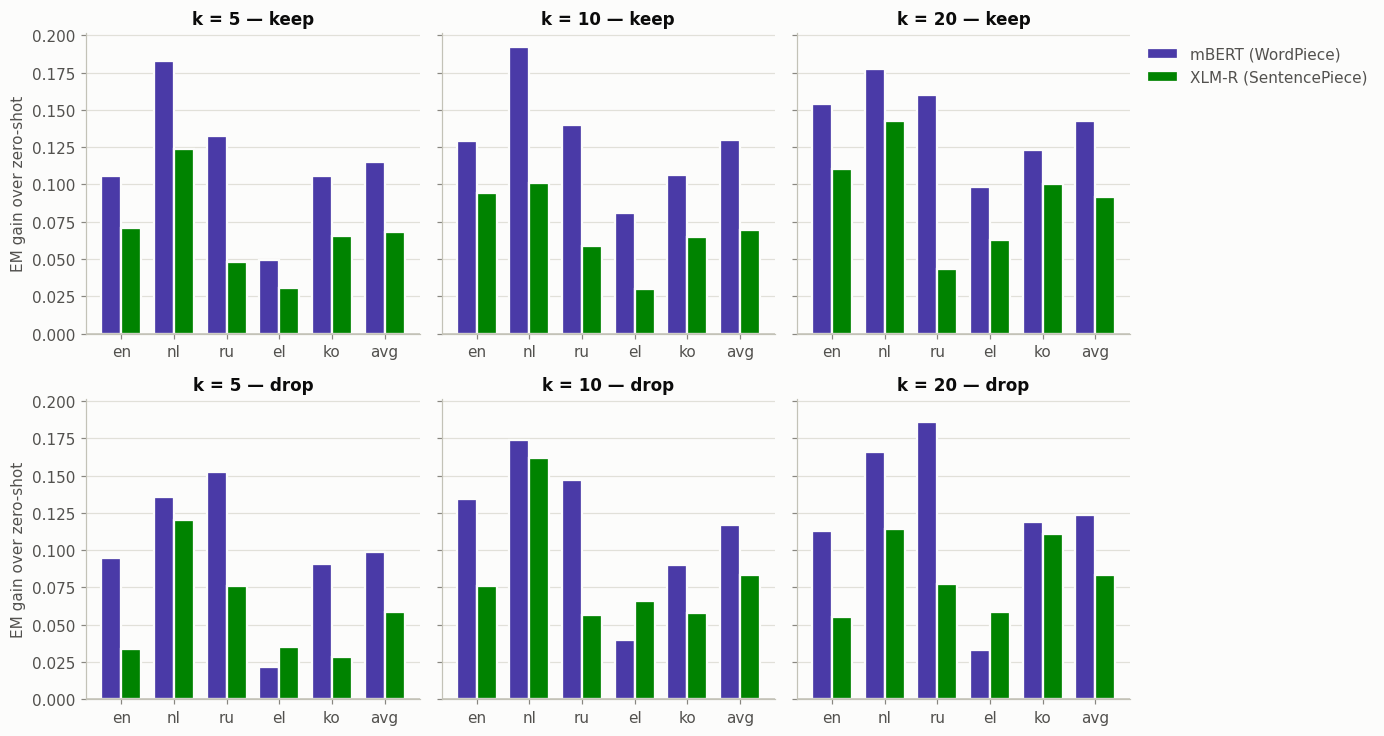

**Average over languages**

zero_shot  prompt_em   gain
variant model      k                              
drop    mbert_base 5       0.219      0.318  0.099
                   10      0.219      0.336  0.117
                   20      0.219      0.342  0.123
        xlmr_base  5       0.117      0.176  0.059
                   10      0.117      0.201  0.084
                   20      0.117      0.200  0.083
keep    mbert_base 5       0.192      0.308  0.115
                   10      0.192      0.322  0.130
                   20      0.192      0.335  0.143
        xlmr_base  5       0.112      0.180  0.068
                   10      0.112      0.182  0.070
                   20      0.112      0.204  0.092

In [19]:
zero = (at_selected[(at_selected.subset == "all") & (at_selected.member == "zero_shot")]
        [["variant", "model", "lang", "test"]].rename(columns={"test": "zero_shot"}))
gains = capacity.merge(zero, on=["variant", "model", "lang"])
gains["gain"] = gains.test - gains.zero_shot

fig, axes = plt.subplots(len(VARIANT_NAMES), len(KS), figsize=(4.2 * len(KS), 3.4 * len(VARIANT_NAMES)),
                         sharey=True, squeeze=False)
width = 0.38
x = np.arange(len(LANGS) + 1)  # languages + average
for r, variant in enumerate(VARIANT_NAMES):
    for c, k in enumerate(KS):
        ax = axes[r, c]
        for i, model in enumerate(MODELS):
            d = gains[(gains.variant == variant) & (gains.k == k) & (gains.model == model)].set_index("lang")
            values = [d.gain.get(lang, np.nan) for lang in LANGS] + [d.gain.mean()]
            ax.bar(x + (i - (len(MODELS) - 1) / 2) * width, values, width, color=MODEL_COLORS[model],
                   edgecolor=SURFACE, linewidth=1.5, label=MODEL_LABELS.get(model, model))
        ax.axhline(0, color=AXIS, linewidth=1)
        ax.set_xticks(x, LANGS + ["avg"])
        ax.set_title(f"k = {k} — {variant}")
        if c == 0:
            ax.set_ylabel("EM gain over zero-shot")
axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
save(fig, "2_model_gains")
plt.show()

display(Markdown("**Average over languages**"))
display(gains.groupby(["variant", "model", "k"])[["zero_shot", "test", "gain"]].mean()
        .rename(columns={"test": "prompt_em"}).round(3))

In [20]:
# Tokenizer view: how many test facts have a single-token vs multi-token gold answer per model.
counts = (at_selected[(at_selected.member == "zero_shot") & (at_selected.subset != "all")]
          .pivot_table(index=["variant", "lang"], columns=["model", "subset"], values="n"))
display(Markdown("**Test facts by gold answer length** (SentencePiece usually splits more names into several pieces)"))
display(counts)

**Test facts by gold answer length** (SentencePiece usually splits more names into several pieces)

model        mbert_base        xlmr_base       
subset            multi single     multi single
variant lang                                   
drop    el          796     69       803     90
        en          366    561       494    433
        ko          820    103       813    112
        nl          498    429       652    271
        ru          782    139       835     82
keep    el          994     71      1022    103
        en          542    619       684    476
        ko         1011    141      1000    155
        nl          686    471       855    298
        ru          980    172      1035    114

## Length-weighted score normalisation

Candidate score = Σ log p(token) / L<sup>α</sup>. α = 0 is the raw sum (long candidates decay
exponentially), α = 1 the per-token mean. Lines are averaged over languages; one line per k.

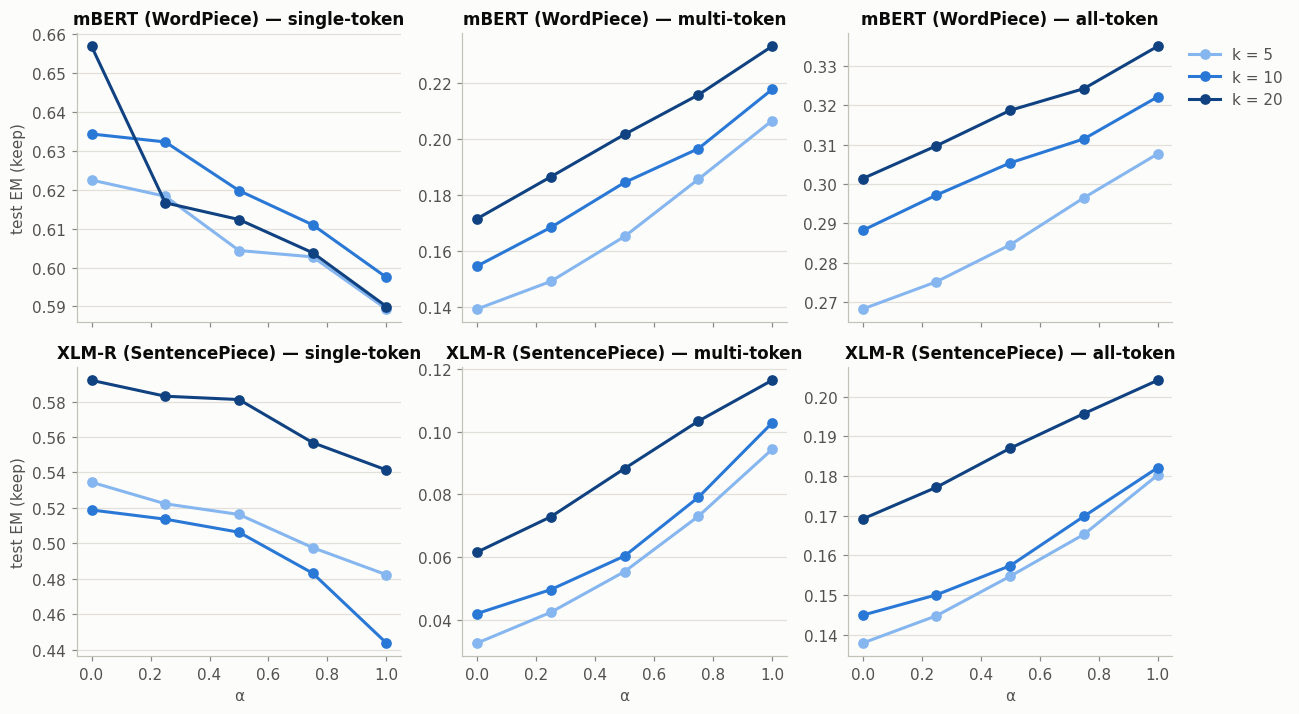

**α selected on validation** (count of model × language runs)

alpha,0.75,1.00
variant,,
drop,1,9
keep,0,10


**Best single prompt, multi-token EM: raw sum (α = 0) vs selected α**

,variant,model,lang,member,alpha,test_raw,test_normalised,change
0,drop,mbert_base,el,P20_s42,1.00,0.154,0.196,0.042
1,drop,mbert_base,en,P20_s42,0.75,0.188,0.223,0.035
2,drop,mbert_base,ko,P5_s42,1.00,0.140,0.175,0.036
3,drop,mbert_base,nl,P20_s42,1.00,0.145,0.259,0.114
4,drop,mbert_base,ru,P20_s42,1.00,0.189,0.245,0.057
5,drop,xlmr_base,el,P10_s42,1.00,0.029,0.089,0.059
6,drop,xlmr_base,en,P10_s42,1.00,0.067,0.156,0.089
7,drop,xlmr_base,ko,P20_s42,1.00,0.089,0.124,0.035
8,drop,xlmr_base,nl,P10_s42,1.00,0.034,0.161,0.128
9,drop,xlmr_base,ru,P20_s42,1.00,0.073,0.116,0.043


In [21]:
norm = (members[(members.variant == FOCUS) & (members.k > 0)]
        .groupby(["model", "subset", "k", "alpha"], as_index=False).test.mean())
subsets = ["single", "multi", "all"]
fig, axes = plt.subplots(len(MODELS), 3, figsize=(12, 3.3 * len(MODELS)), sharex=True, squeeze=False)
for r, model in enumerate(MODELS):
    for c, subset in enumerate(subsets):
        ax = axes[r, c]
        for k in KS:
            d = norm[(norm.model == model) & (norm.subset == subset) & (norm.k == k)].sort_values("alpha")
            ax.plot(d.alpha, d.test, marker="o", color=K_COLORS[k], label=f"k = {k}")
        ax.set_title(f"{MODEL_LABELS.get(model, model)} — {subset}-token")
        if r == len(MODELS) - 1:
            ax.set_xlabel("α")
        if c == 0:
            ax.set_ylabel(f"test EM ({FOCUS})")
axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
save(fig, f"3_length_normalisation_{FOCUS}")
plt.show()

display(Markdown("**α selected on validation** (count of model × language runs)"))
display(selection.pivot_table(index="variant", columns="alpha", values="lang", aggfunc="count").fillna(0).astype(int))

raw = members[(members.alpha == 0) & (members.subset == "multi")][["variant", "model", "lang", "member", "test"]]
best = (at_selected[at_selected.subset == "multi"]
        .merge(selection[["variant", "model", "lang", "best_member"]],
               left_on=["variant", "model", "lang", "member"],
               right_on=["variant", "model", "lang", "best_member"]))
effect = best.merge(raw, on=["variant", "model", "lang", "member"], suffixes=("_normalised", "_raw"))
effect["change"] = effect.test_normalised - effect.test_raw
display(Markdown("**Best single prompt, multi-token EM: raw sum (α = 0) vs selected α**"))
display(effect[["variant", "model", "lang", "member", "alpha", "test_raw", "test_normalised", "change"]]
        .sort_values(["variant", "model", "lang"]).round(3).reset_index(drop=True))

## Ensembling with learnable scalar weights

All systems at the validation-selected α. *Best single prompt* is chosen on validation, so it is a
fair, strong baseline for the ensemble.

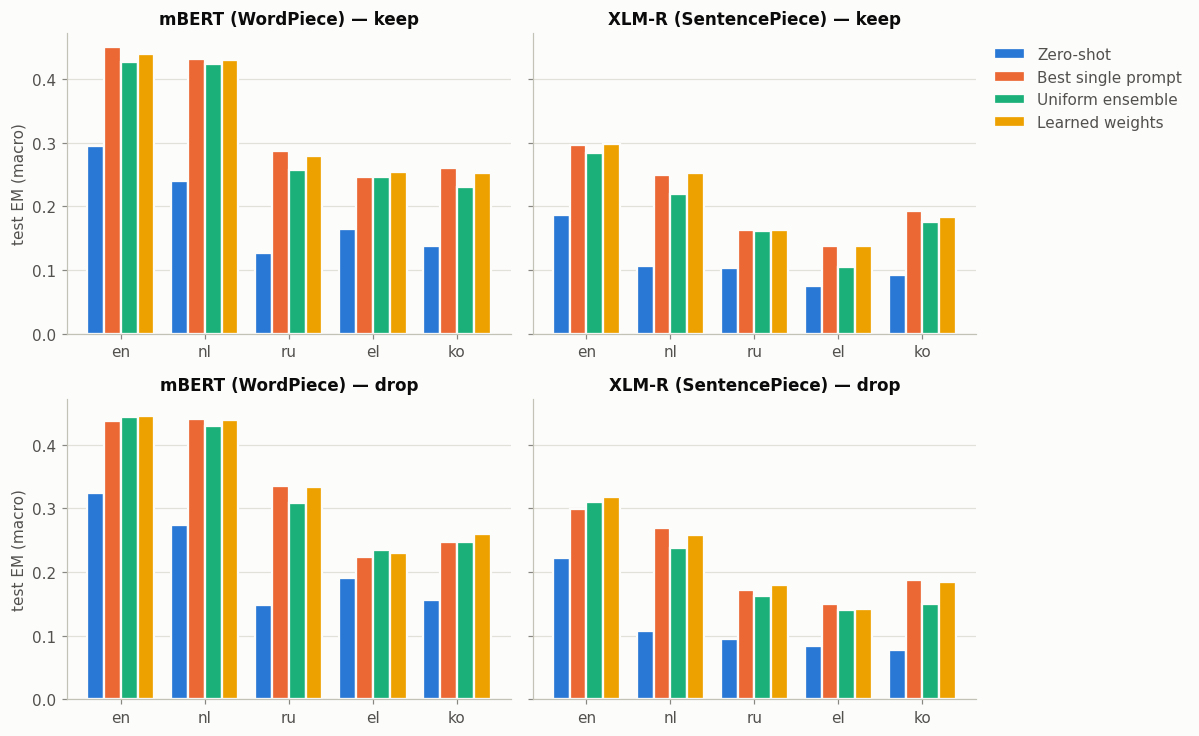

,variant,model,lang,zero_shot,best_single,uniform,learned,learned_minus_best
0,keep,mbert_base,el,0.164,0.245,0.245,0.254,0.008
1,keep,mbert_base,en,0.295,0.449,0.427,0.440,-0.010
2,keep,mbert_base,ko,0.138,0.261,0.230,0.252,-0.009
3,keep,mbert_base,nl,0.239,0.431,0.423,0.429,-0.001
4,keep,mbert_base,ru,0.126,0.286,0.258,0.279,-0.007
5,keep,xlmr_base,el,0.075,0.138,0.105,0.138,0.000
6,keep,xlmr_base,en,0.186,0.296,0.283,0.298,0.002
7,keep,xlmr_base,ko,0.092,0.193,0.175,0.183,-0.010
8,keep,xlmr_base,nl,0.106,0.248,0.219,0.252,0.004
9,keep,xlmr_base,ru,0.103,0.162,0.161,0.163,0.001


**Mean over languages**

zero_shot  best_single  uniform  learned  \
variant model                                                  
drop    mbert_base     0.2187       0.3364   0.3325   0.3416   
        xlmr_base      0.1171       0.2155   0.1998   0.2164   
keep    mbert_base     0.1925       0.3345   0.3166   0.3307   
        xlmr_base      0.1124       0.2073   0.1889   0.2068   

                    learned_minus_best  
variant model                           
drop    mbert_base              0.0051  
        xlmr_base               0.0009  
keep    mbert_base             -0.0037  
        xlmr_base              -0.0006

In [26]:
rows = []
for _, sel in selection.iterrows():
    key = (members.variant == sel.variant) & (members.model == sel.model) & \
          (members.lang == sel.lang) & (members.alpha == sel.alpha) & (members.subset == "all")
    get = lambda name: members[key & (members.member == name)].test.squeeze()
    sys_key = (systems.variant == sel.variant) & (systems.model == sel.model) & \
              (systems.lang == sel.lang) & (systems.alpha == sel.alpha) & (systems.subset == "all")
    row = dict(variant=sel.variant, model=sel.model, lang=sel.lang,
               zero_shot=get("zero_shot"), best_single=get(sel.best_member))
    for system in ("uniform", "learned"):
        match = systems[sys_key & (systems.system == system)].test
        row[system] = match.squeeze() if len(match) else np.nan
    rows.append(row)
ensembles = pd.DataFrame(rows)
ensembles["learned_minus_best"] = ensembles.learned - ensembles.best_single

fig, axes = plt.subplots(len(VARIANT_NAMES), len(MODELS), figsize=(5.5 * len(MODELS), 3.4 * len(VARIANT_NAMES)),
                         sharey=True, squeeze=False)
width = 0.2
x = np.arange(len(LANGS))
for r, variant in enumerate(VARIANT_NAMES):
    for c, model in enumerate(MODELS):
        ax = axes[r, c]
        d = ensembles[(ensembles.variant == variant) & (ensembles.model == model)].set_index("lang")
        for i, system in enumerate(SYSTEM_ORDER):
            values = [d[system].get(lang, np.nan) for lang in LANGS]
            ax.bar(x + (i - 1.5) * width, values, width, color=SYSTEM_COLORS[system],
                   edgecolor=SURFACE, linewidth=1.5, label=SYSTEM_LABELS[system])
        ax.set_xticks(x, LANGS)
        ax.set_title(f"{MODEL_LABELS.get(model, model)} — {variant}")
        if c == 0:
            ax.set_ylabel("test EM (macro)")
axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
save(fig, "4_ensembles")
plt.show()

display(ensembles.round(3))
display(Markdown("**Mean over languages**"))
display(ensembles.groupby(["variant", "model"])[["zero_shot", "best_single", "uniform", "learned",
                                                 "learned_minus_best"]].mean().round(4))

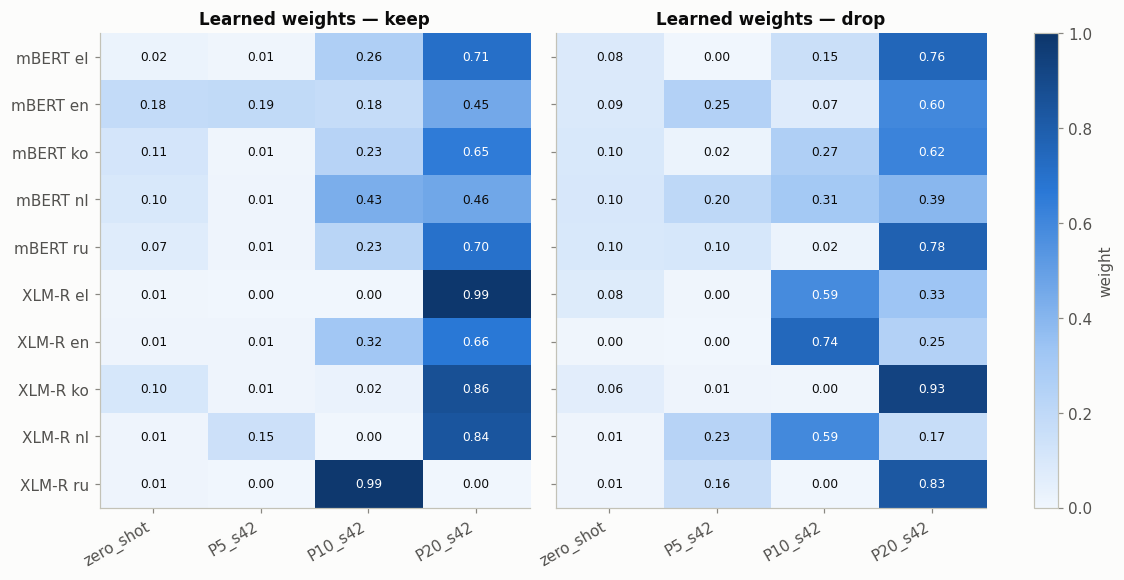

**Largest weight per run**

,variant,model,lang,top_member,top_weight
0,drop,mbert_base,el,P20_s42,0.76
1,drop,mbert_base,en,P20_s42,0.60
2,drop,mbert_base,ko,P20_s42,0.62
3,drop,mbert_base,nl,P20_s42,0.39
4,drop,mbert_base,ru,P20_s42,0.78
5,drop,xlmr_base,el,P10_s42,0.59
6,drop,xlmr_base,en,P10_s42,0.74
7,drop,xlmr_base,ko,P20_s42,0.93
8,drop,xlmr_base,nl,P10_s42,0.59
9,drop,xlmr_base,ru,P20_s42,0.83


In [27]:
if weights.empty:
    print("No learned weights found: ensemble.json files need at least two members.")
else:
    def member_key(m):
        match = MEMBER.match(m)
        return tuple(map(int, match.groups())) if match else (0, 0)

    member_order = ["zero_shot"] + sorted((m for m in weights.member.unique() if m != "zero_shot"), key=member_key)
    tables = {v: weights[weights.variant == v].pivot_table(index=["model", "lang"], columns="member", values="weight")
                 .reindex(columns=member_order)
              for v in VARIANT_NAMES if (weights.variant == v).any()}
    rows = max(len(t) for t in tables.values())

    fig, axes = plt.subplots(1, len(tables), figsize=(1.1 * len(member_order) * len(tables) + 2.5, 0.42 * rows + 1.4),
                             squeeze=False)
    for c, (ax, (variant, w)) in enumerate(zip(axes[0], tables.items())):
        image = ax.imshow(w.values, cmap=BLUES, vmin=0, vmax=1, aspect="auto")
        ax.set_xticks(range(len(member_order)), member_order, rotation=30, ha="right")
        # Same rows in every panel: label them once, on the left.
        labels = [f"{MODEL_LABELS.get(m, m).split()[0]} {l}" for m, l in w.index] if c == 0 else []
        ax.set_yticks(range(len(w)), labels)
        ax.grid(False)
        for i in range(w.shape[0]):
            for j in range(w.shape[1]):
                value = w.values[i, j]
                if not np.isnan(value):
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                            color="#ffffff" if value > 0.55 else INK)
        ax.set_title(f"Learned weights — {variant}")
    fig.subplots_adjust(wspace=0.06)
    fig.colorbar(image, ax=axes[0].tolist(), fraction=0.03, label="weight")
    save(fig, "4b_weights")
    plt.show()

    display(Markdown("**Largest weight per run**"))
    top = weights.loc[weights.groupby(["variant", "model", "lang"]).weight.idxmax()]
    display(top.rename(columns={"member": "top_member", "weight": "top_weight"})
            .reset_index(drop=True).round(2))

## 5. Keep vs drop

**Caveat:** the two variants are evaluated on different test sets (`drop` removes facts), so a
difference mixes *training on cleaner data* with *testing on easier/cleaner facts*. Languages
without inflection (en, nl, ko) show how much the test-set change alone moves the numbers.
A fair comparison evaluates the `keep` prompts on the `drop` test set (it is a subset).

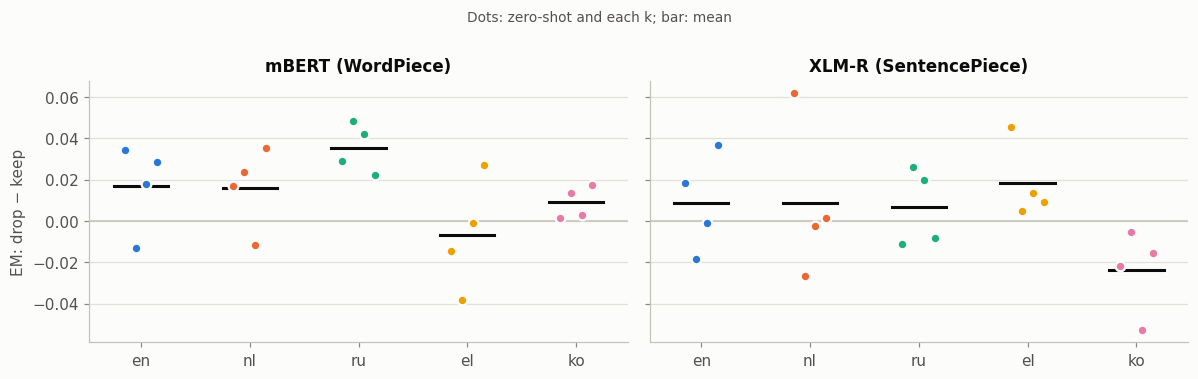

member           P10_s42  P20_s42  P5_s42  zero_shot
model      lang                                     
mbert_base el     -0.014   -0.038  -0.001      0.027
           en      0.034   -0.013   0.018      0.029
           ko      0.002    0.014   0.003      0.018
           nl      0.017    0.024  -0.012      0.035
           ru      0.029    0.049   0.042      0.022
xlmr_base  el      0.046    0.005   0.014      0.009
           en      0.018   -0.018  -0.001      0.037
           ko     -0.022   -0.005  -0.053     -0.015
           nl      0.062   -0.027  -0.003      0.001
           ru     -0.011    0.026   0.020     -0.008

In [23]:
if {"keep", "drop"} <= set(VARIANT_NAMES):
    both = (at_selected[at_selected.subset == "all"]
            .pivot_table(index=["model", "lang", "member", "k"], columns="variant", values="test")
            .dropna().reset_index())
    both["drop_minus_keep"] = both["drop"] - both["keep"]

    fig, axes = plt.subplots(1, len(MODELS), figsize=(5.5 * len(MODELS), 3.4), sharey=True, squeeze=False)
    for c, model in enumerate(MODELS):
        ax = axes[0, c]
        d = both[both.model == model]
        for i, lang in enumerate(LANGS):
            values = d[d.lang == lang].drop_minus_keep
            ax.scatter(np.full(len(values), i) + np.linspace(-0.15, 0.15, len(values)), values,
                       s=40, color=LANG_COLORS[lang], edgecolor=SURFACE, linewidth=1.5, zorder=3)
            ax.plot([i - 0.25, i + 0.25], [values.mean()] * 2, color=INK, linewidth=2)
        ax.axhline(0, color=AXIS, linewidth=1)
        ax.set_xticks(range(len(LANGS)), LANGS)
        ax.set_title(MODEL_LABELS.get(model, model))
        if c == 0:
            ax.set_ylabel("EM: drop − keep")
    fig.suptitle("Dots: zero-shot and each k; bar: mean", color=INK2, fontsize=9, y=1.0)
    fig.tight_layout()
    save(fig, "5_keep_vs_drop")
    plt.show()

    display(both.pivot_table(index=["model", "lang"], columns="member",
                             values="drop_minus_keep").round(3))
else:
    print("Need both variants for this section.")

## Training curves

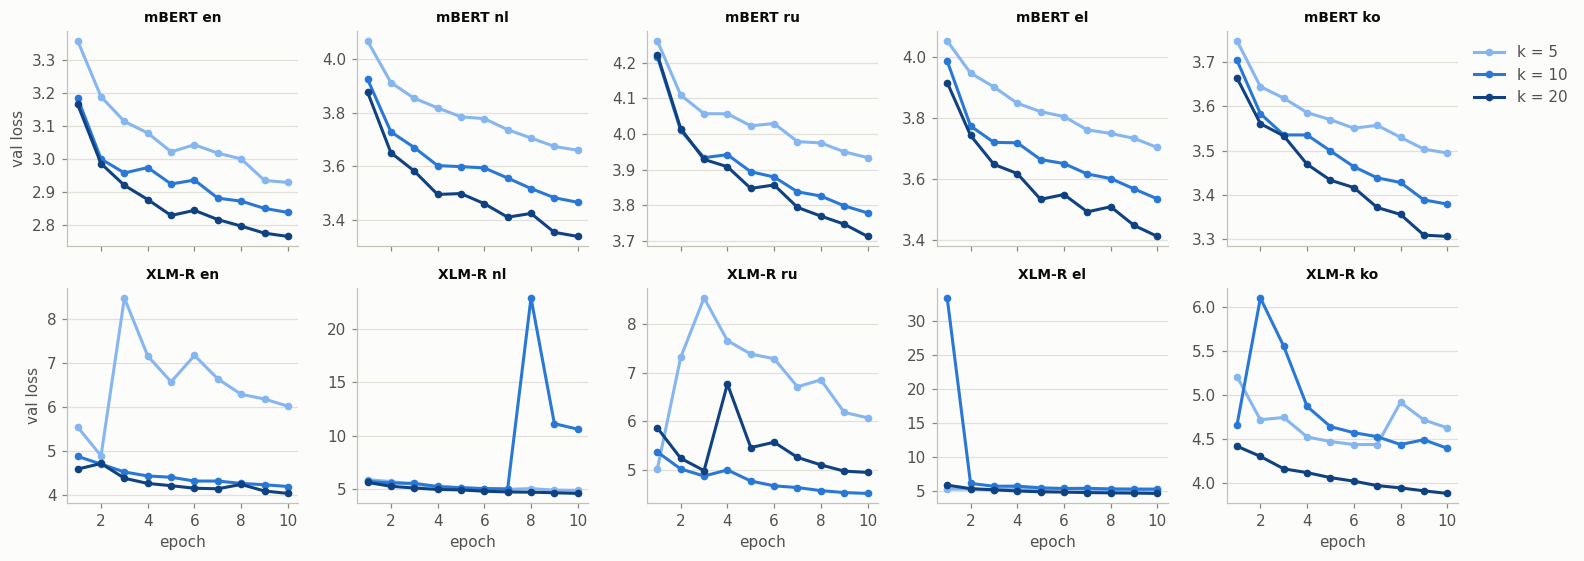

**Best epoch per run**

k                        5   10  20
variant model      lang            
drop    mbert_base el    10  10  10
                   en    10  10  10
                   ko    10  10  10
                   nl    10  10  10
                   ru    10  10  10
        xlmr_base  el     1  10   2
                   en     1  10  10
                   ko    10  10  10
                   nl     3  10  10
                   ru     4   1  10
keep    mbert_base el    10  10  10
                   en    10  10  10
                   ko    10  10  10
                   nl    10  10  10
                   ru    10  10  10
        xlmr_base  el    10  10  10
                   en     2  10  10
                   ko     6  10  10
                   nl    10   7  10
                   ru     1  10  10

Runs whose best epoch is the last epoch: 50 / 60


In [24]:
if len(history):
    h = history[history.variant == FOCUS]
    fig, axes = plt.subplots(len(MODELS), len(LANGS), figsize=(2.9 * len(LANGS), 2.6 * len(MODELS)),
                             sharex=True, squeeze=False)
    for r, model in enumerate(MODELS):
        for c, lang in enumerate(LANGS):
            ax = axes[r, c]
            for k in KS:
                d = h[(h.model == model) & (h.lang == lang) & (h.k == k)].groupby("epoch").val_loss.mean()
                ax.plot(d.index, d.values, marker="o", markersize=4, color=K_COLORS[k], label=f"k = {k}")
            ax.set_title(f"{MODEL_LABELS.get(model, model).split()[0]} {lang}", fontsize=9)
            if c == 0:
                ax.set_ylabel("val loss")
            if r == len(MODELS) - 1:
                ax.set_xlabel("epoch")
    axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    fig.tight_layout()
    save(fig, f"6_training_curves_{FOCUS}")
    plt.show()

    best_epoch = (history.loc[history.groupby(["variant", "model", "lang", "k", "seed"]).val_loss.idxmin()]
                  [["variant", "model", "lang", "k", "seed", "epoch", "val_loss", "val_acc"]])
    best_epoch["last_epoch"] = best_epoch.merge(
        history.groupby(["variant", "model", "lang", "k", "seed"], as_index=False).epoch.max(),
        on=["variant", "model", "lang", "k", "seed"], suffixes=("", "_max")).epoch_max.values
    display(Markdown("**Best epoch per run**"))
    display(best_epoch.pivot_table(index=["variant", "model", "lang"], columns="k", values="epoch"))
    print(f"Runs whose best epoch is the last epoch: "
          f"{(best_epoch.epoch == best_epoch.last_epoch).sum()} / {len(best_epoch)}")
else:
    print("No training histories found (copy checkpoints/*/history_*.json to see them).")

In [28]:
VARIANTS = {
    "keep": {"results": ROOT / "results" / "ablation_keep",
             "checkpoints": ROOT / "checkpoints" / "ablation_keep"},
    "drop": {"results": ROOT / "results" / "ablation_drop",
             "checkpoints": ROOT / "checkpoints" / "ablation_drop"},
    "xlmr_lr0.05": {"results": ROOT / "results" / "ablation_keep_xlmr_lr005",
                    "checkpoints": ROOT / "checkpoints" / "ablation_keep_xlmr_lr005"},
    "mbert_ep20": {"results": ROOT / "results" / "ablation_keep_mbert_ep20",
                   "checkpoints": ROOT / "checkpoints" / "ablation_keep_mbert_ep20"},
}


**Best epoch per run** (lowest validation loss)

run  lr 0.05         lr 0.3        
k         5   10  20     5   10  20
lang                               
en        10  10   2      2  10  10
nl        10  10  10     10   7  10
ru        10   8  10      1  10  10
el         2   4   7     10  10  10
ko        10   6  10      6  10  10

,runs,best_at_epoch_1_or_2,best_at_last_epoch
run,,,
lr 0.05,15,2,9
lr 0.3,15,2,11


**Dutch, k = 5 and 10: validation accuracy per epoch**

run   lr 0.05        lr 0.3       
k          5      10     5      10
epoch                             
1       0.000  0.000  0.127  0.141
2       0.002  0.030  0.144  0.145
3       0.001  0.064  0.165  0.150
4       0.011  0.070  0.187  0.189
5       0.022  0.075  0.207  0.200
6       0.015  0.065  0.224  0.214
7       0.037  0.070  0.222  0.205
8       0.048  0.068  0.205  0.000
9       0.045  0.077  0.233  0.000
10      0.056  0.078  0.232  0.000

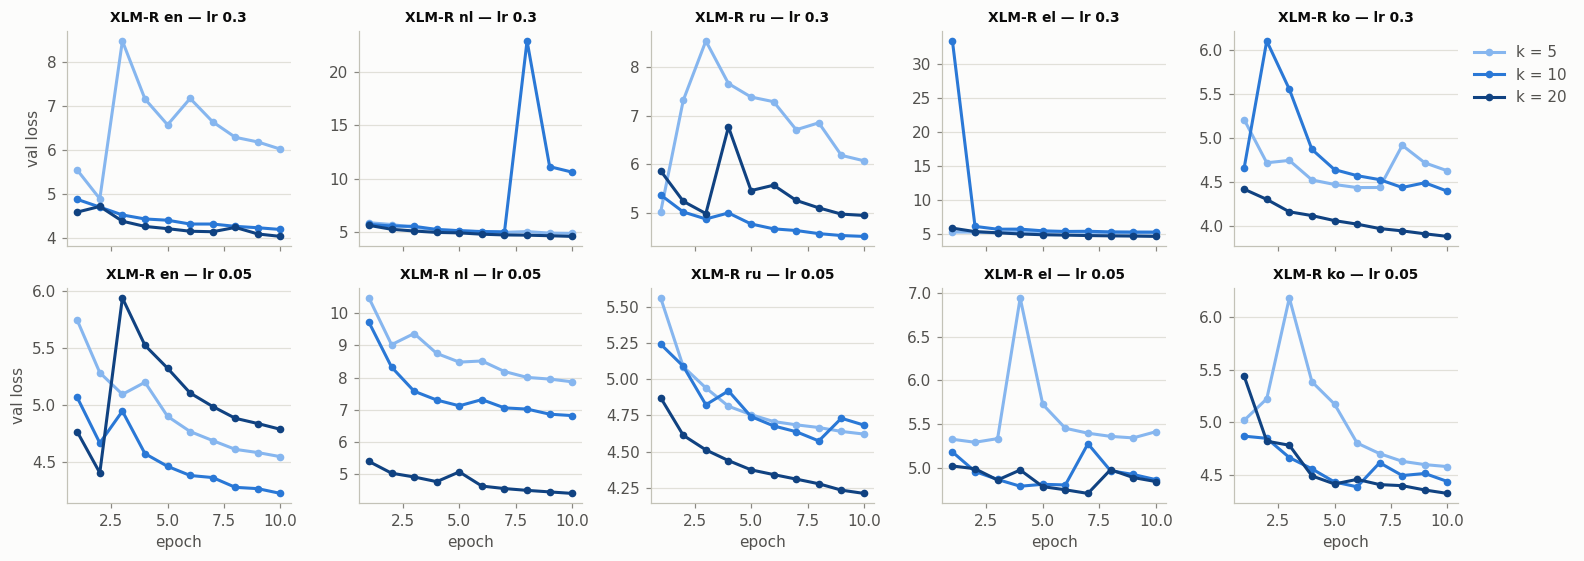

In [29]:
# XLM-R training stability: learning rate 0.3 (original keep run) vs 0.05.
# Reads checkpoints/<run>/xlmr_base/<lang>/P<k>_seed<s>/history_<lang>_P<k>.json
LR_RUNS = {
    "lr 0.3": ROOT / "checkpoints" / "ablation_keep",
    "lr 0.05": ROOT / "checkpoints" / "ablation_keep_xlmr_lr005",
}

rows = []
for run, root in LR_RUNS.items():
    for file in root.glob("xlmr_base/*/P*_seed*/history_*.json"):
        k, seed = map(int, HISTORY_DIR.match(file.parent.name).groups())
        for row in json.loads(file.read_text(encoding="utf-8")):
            rows.append(dict(run=run, lang=file.parent.parent.name, k=k, seed=seed, **row))
lr_hist = pd.DataFrame(rows)
assert len(lr_hist), "No XLM-R histories found - check the folders in LR_RUNS."

runs = [r for r in LR_RUNS if r in set(lr_hist.run)]
langs = ordered(lr_hist.lang, LANG_ORDER)
ks = sorted(lr_hist.k.unique())
colors = k_colors(ks)
last_epoch = lr_hist.groupby("run").epoch.max()

# Best (lowest validation loss) epoch per run - this checkpoint is the one evaluated.
best = lr_hist.loc[lr_hist.groupby(["run", "lang", "k", "seed"]).val_loss.idxmin()]
display(Markdown("**Best epoch per run** (lowest validation loss)"))
display(best.pivot_table(index="lang", columns=["run", "k"], values="epoch").reindex(langs))

summary = best.groupby("run").agg(runs=("epoch", "size"),
                                  best_at_epoch_1_or_2=("epoch", lambda e: int((e <= 2).sum())))
summary["best_at_last_epoch"] = [int((best[best.run == r].epoch == last_epoch[r]).sum()) for r in summary.index]
display(summary)

# Did the weak Dutch prompts learn at all? Validation accuracy per epoch.
display(Markdown("**Dutch, k = 5 and 10: validation accuracy per epoch**"))
display(lr_hist[(lr_hist.lang == "nl") & (lr_hist.k.isin([5, 10]))]
        .pivot_table(index="epoch", columns=["run", "k"], values="val_acc").round(3))

# Validation-loss curves: rows = learning rate, columns = language, one line per k.
fig, axes = plt.subplots(len(runs), len(langs), figsize=(2.9 * len(langs), 2.6 * len(runs)),
                         sharex=True, squeeze=False)
for r, run in enumerate(runs):
    for c, lang in enumerate(langs):
        ax = axes[r, c]
        for k in ks:
            d = lr_hist[(lr_hist.run == run) & (lr_hist.lang == lang) & (lr_hist.k == k)].groupby("epoch").val_loss.mean()
            ax.plot(d.index, d.values, marker="o", markersize=4, color=colors[k], label=f"k = {k}")
        ax.set_title(f"XLM-R {lang} — {run}", fontsize=9)
        if c == 0:
            ax.set_ylabel("val loss")
        if r == len(runs) - 1:
            ax.set_xlabel("epoch")
axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1.01, 1))
fig.tight_layout()
save(fig, "6b_xlmr_learning_rate")
plt.show()


## Export

In [25]:
for name, frame in [("capacity", capacity), ("gains", gains), ("ensembles", ensembles),
                    ("members_all_alphas", members), ("selection", selection)]:
    frame.to_csv(FIG_DIR / f"{name}.csv", index=False)
print(f"Saved figures and tables to {FIG_DIR}")

Saved figures and tables to /gpfs/home6/scur0540/Multilingual_NLP_Project/results/analysis_figures
